# Dehazing Configuration Evaluation


## 1. Setup and Parameter Extraction


In [ ]:
import os
import cv2
import optuna
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Add project root to path
import sys
sys.path.append(os.path.abspath('.'))

from src.filters.dark_channel_prior import dehaze
from src.utils.yolo26 import try_load_ultralytics_model
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pyiqa

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
niqe_metric = pyiqa.create_metric('niqe', as_loss=False).to(device)
brisque_metric = pyiqa.create_metric('brisque', as_loss=False).to(device)

def get_best_params(db_url, study_name):
    try:
        study = optuna.load_study(study_name=study_name, storage=db_url)
        best_trial = study.best_trials[0]
        return best_trial.params
    except Exception as e:
        print(f'Error loading {study_name}: {e}')
        # Return fallback default parameters
        return {'patch_size': 15, 'omega': 0.95, 't0': 0.1}

config_gt = get_best_params('sqlite:///optuna_gt.db', 'dcp_gt_optimization')
config_nogt = get_best_params('sqlite:///optuna_nogt.db', 'dcp_nogt_optimization')
config_yolo = get_best_params('sqlite:///optuna_yolo.db', 'dcp_yolo_optimization')

print('Config 1 (RESIDE-6K GT):', config_gt)
print('Config 2 (DAWN No-GT):', config_nogt)
print('Config 3 (YOLO Detection):', config_yolo)



Config 1 (RESIDE-6K GT): {'omega': 0.7588890171023668, 't0': 0.18989472917172184, 'patch_size': 19}
Config 2 (DAWN No-GT): {'omega': 0.7929507184099119, 't0': 0.16030151067031612, 'patch_size': 7}
Config 3 (YOLO Detection): {'omega': 0.7737529469719686, 't0': 0.14736226091269483, 'patch_size': 5}


## 2. Sample Image Selection


In [ ]:
# Define paths to 2 RESIDE-6K images and 2 DAWN images
reside_root = r'C:\Users\manh hung\.cache\kagglehub\datasets\kmljts\reside-6k\versions\1\RESIDE-6K'
dawn_root = 'data\processed\dawn_yolo'

sample_images = [
    # (Hazy Path, Clear/GT Path or None, Dataset Name)
    (os.path.join(reside_root, 'train/hazy/1.jpg'), os.path.join(reside_root, 'train/GT/1.jpg'), 'RESIDE-6K'),
    (os.path.join(reside_root, 'train/hazy/10.jpg'), os.path.join(reside_root, 'train/GT/10.jpg'), 'RESIDE-6K'),
    (os.path.join(dawn_root, 'images/train/Fog/20190802_105216.jpg'), None, 'DAWN'),
    (os.path.join(dawn_root, 'images/train/Fog/20190802_105432.jpg'), None, 'DAWN')
]

# Verify existence
for path, gt, name in sample_images:
    if not os.path.exists(path):
        print(f'Warning: Sample image not found: {path}')



## 3. Restoration and Metrics Comparison


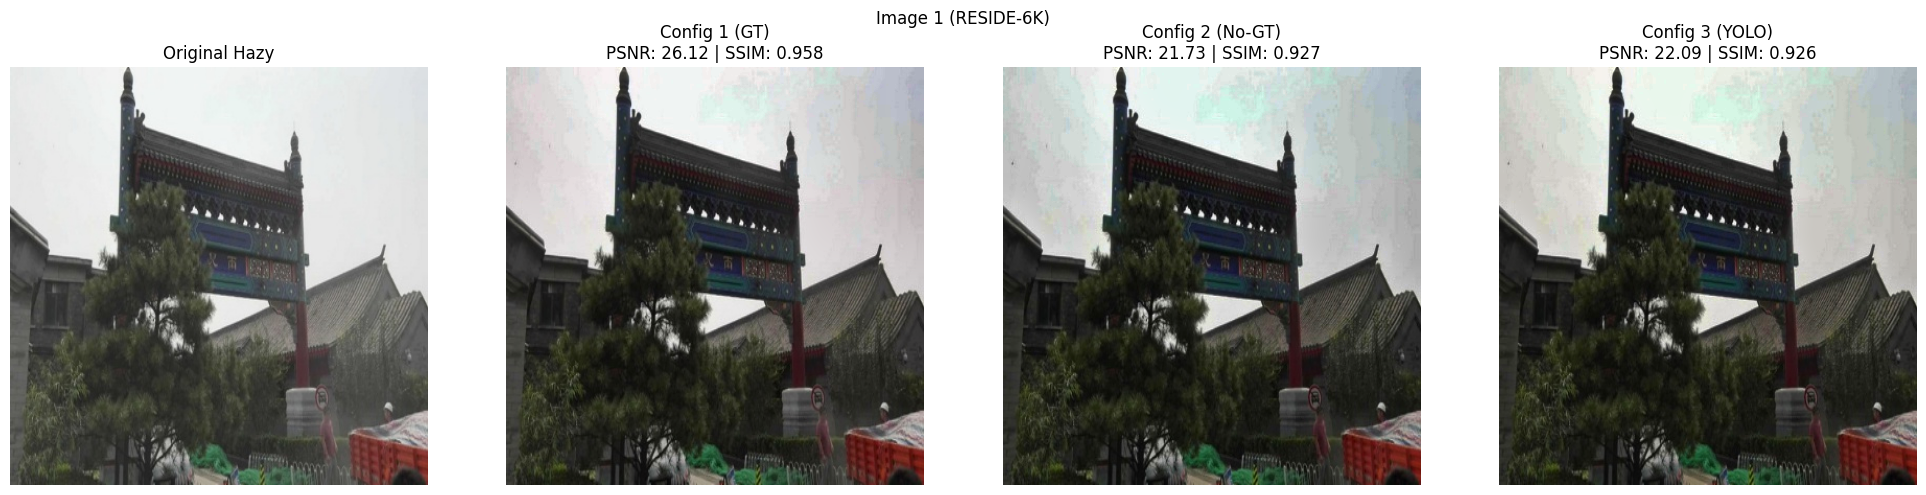

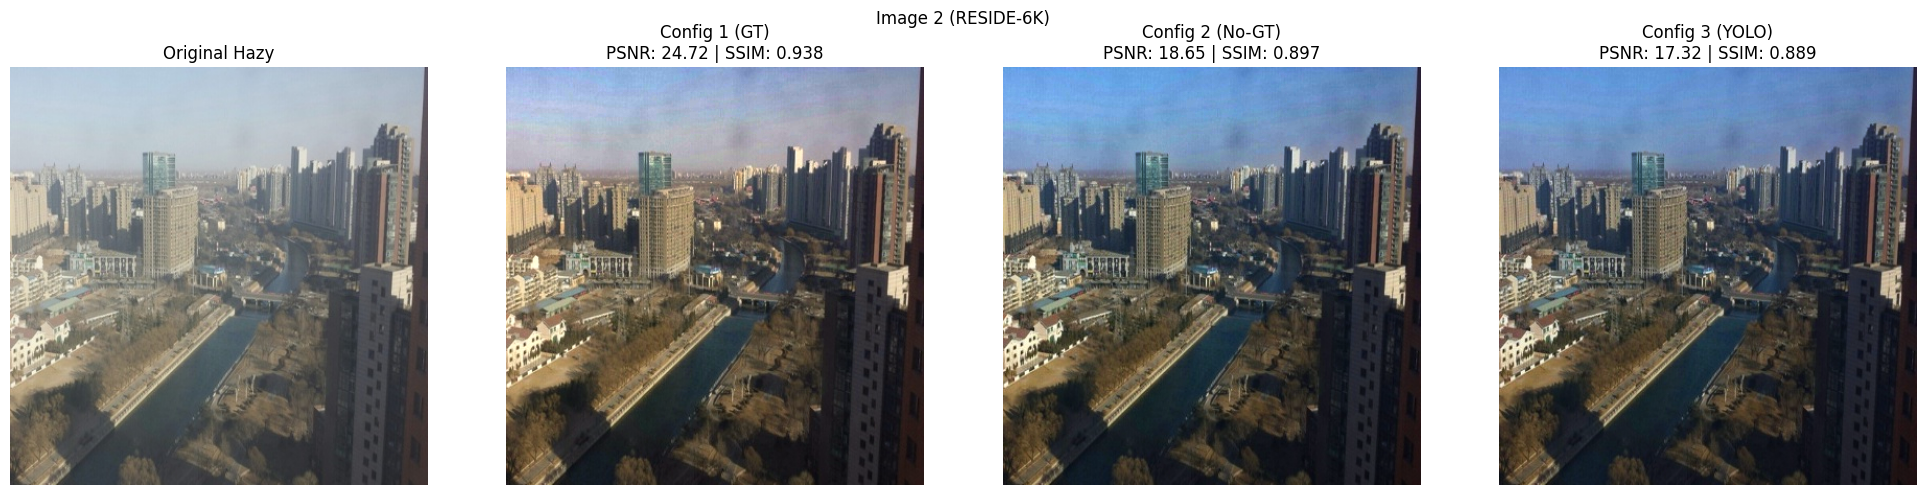

In [ ]:
def calc_no_ref_metrics(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(img_rgb).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(device)
    with torch.no_grad():
        n = niqe_metric(img_tensor).item()
        b = brisque_metric(img_tensor).item()
    return n, b

configs = {
    'Config 1 (GT)': config_gt,
    'Config 2 (No-GT)': config_nogt,
    'Config 3 (YOLO)': config_yolo
}

results_cache = []

for idx, (hazy_path, gt_path, ds_name) in enumerate(sample_images):
    if not os.path.exists(hazy_path): continue
    
    hazy = cv2.imread(hazy_path)
    gt = cv2.imread(gt_path) if gt_path and os.path.exists(gt_path) else None
    
    # Resize GT if necessary
    if gt is not None and hazy.shape != gt.shape:
        gt = cv2.resize(gt, (hazy.shape[1], hazy.shape[0]))
        
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Image {idx+1} ({ds_name})')
    
    axes[0].imshow(cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Hazy')
    axes[0].axis('off')
    
    cache_row = {'original': hazy, 'gt': gt, 'restored': {}}
    
    for i, (cfg_name, cfg_params) in enumerate(configs.items()):
        restored = dehaze(hazy, patch_size=cfg_params['patch_size'], omega=cfg_params['omega'], t0=cfg_params['t0'], refine=True)
        cache_row['restored'][cfg_name] = restored
        
        # Calculate metrics
        title = cfg_name
        if gt is not None:
            p = psnr(gt, restored)
            s = ssim(gt, restored, channel_axis=2)
            title += f'\nPSNR: {p:.2f} | SSIM: {s:.3f}'
        else:
            n, b = calc_no_ref_metrics(restored)
            title += f'\nNIQE: {n:.2f} | BRISQ: {b:.2f}'
            
        axes[i+1].imshow(cv2.cvtColor(restored, cv2.COLOR_BGR2RGB))
        axes[i+1].set_title(title)
        axes[i+1].axis('off')
        
    results_cache.append(cache_row)
    plt.tight_layout()
    plt.show()



## 4. Object Detection Evaluation


YOLO model loaded successfully.


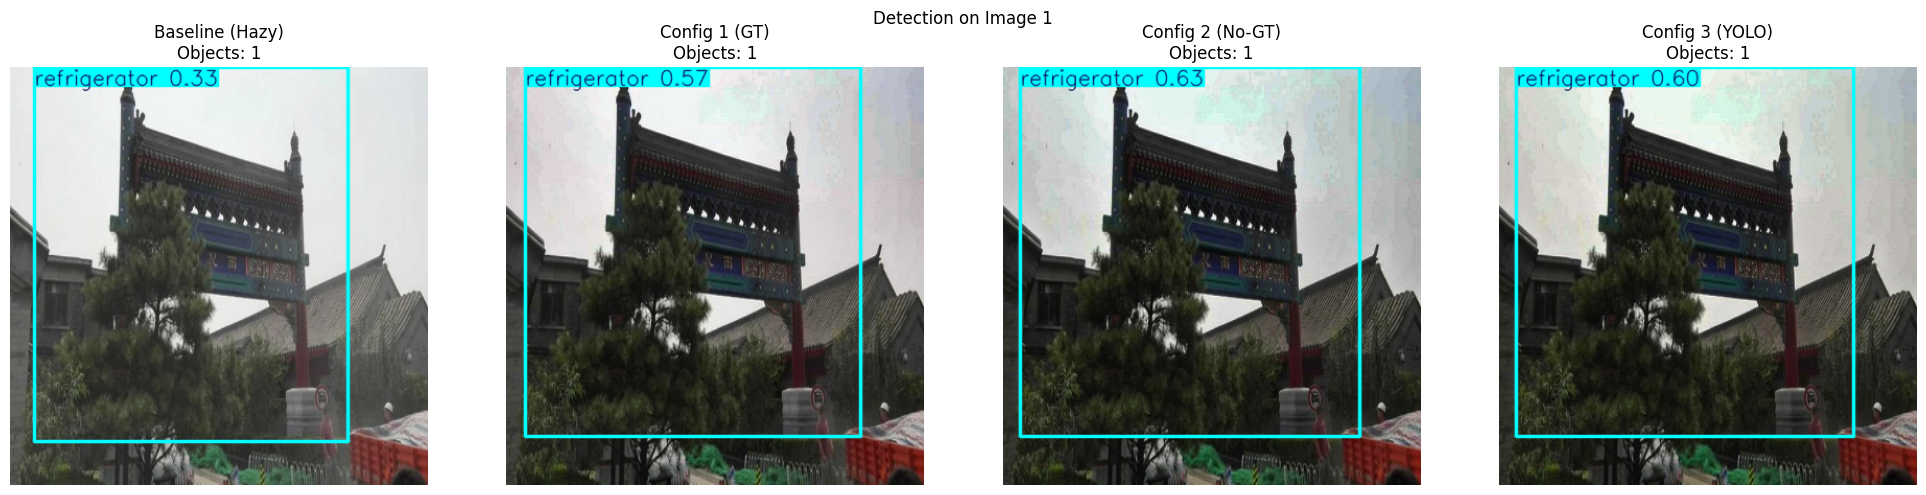

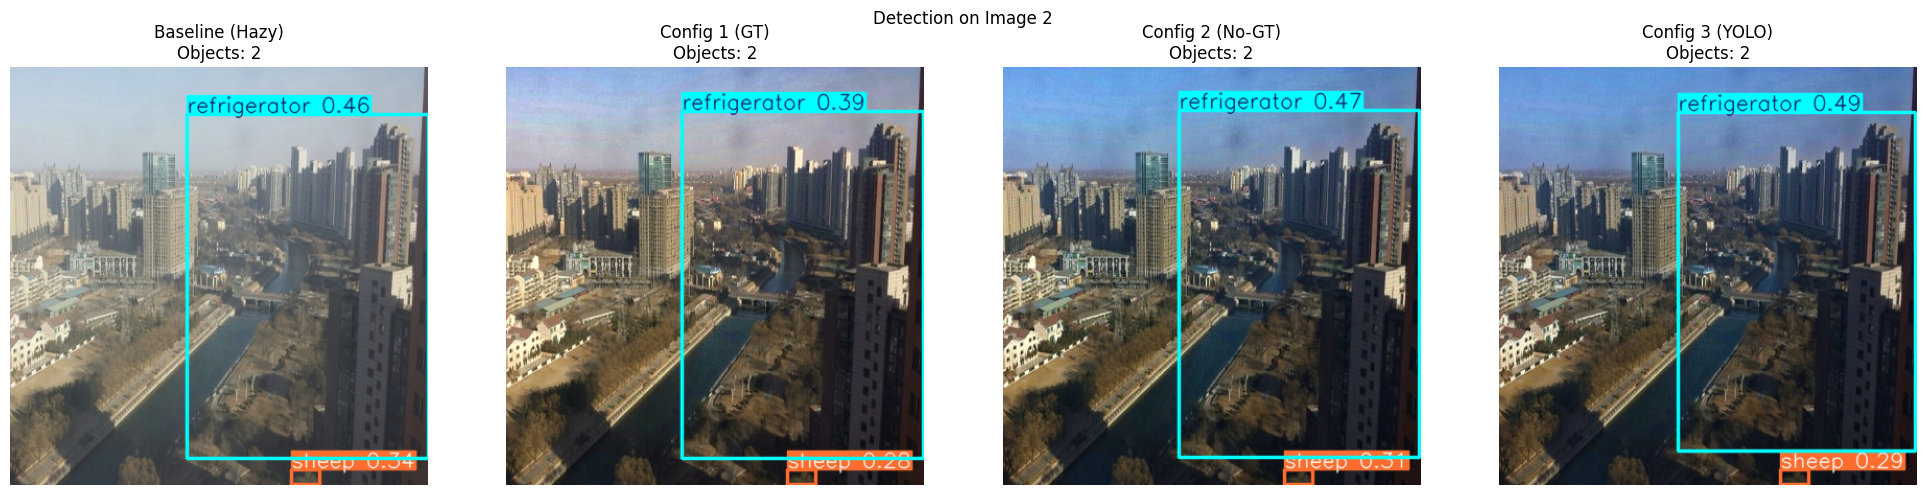

In [ ]:
load_res = try_load_ultralytics_model('yolo26n.pt', allow_fallback=True)
if not load_res.ok:
    print(load_res.message)
else:
    model = load_res.model
    print('YOLO model loaded successfully.')

    for idx, cache in enumerate(results_cache):
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f'Detection on Image {idx+1}')
        
        images_to_test = [('Baseline (Hazy)', cache['original'])]
        for name in configs.keys():
            images_to_test.append((name, cache['restored'][name]))
            
        for i, (name, img) in enumerate(images_to_test):
            results = model(img, verbose=False)[0]
            # Plot results
            res_img = results.plot()
            axes[i].imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
            axes[i].set_title(f'{name}\nObjects: {len(results.boxes)}')
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()

